In [109]:
%pip install pandas matplotlib seaborn scikit-learn numpy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [111]:
#loading train and test data
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

In [112]:
train.head(10)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
5,2011-01-01 05:00:00,1,0,0,2,9.84,12.880,75,6.0032,0,1,1
6,2011-01-01 06:00:00,1,0,0,1,9.02,13.635,80,0.0000,2,0,2
7,2011-01-01 07:00:00,1,0,0,1,8.20,12.880,86,0.0000,1,2,3
8,2011-01-01 08:00:00,1,0,0,1,9.84,14.395,75,0.0000,1,7,8
9,2011-01-01 09:00:00,1,0,0,1,13.12,17.425,76,0.0000,8,6,14


In [113]:
rows, columns = train.shape
print(f'The dataset has {rows} rows and {columns} columns.')

The dataset has 10886 rows and 12 columns.


In [114]:
train.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')

In [115]:
#Checking for null values in the train dataset
train.isnull().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

*Correlation matrix*

Since 'season', 'holiday', 'workingday'and 'weather' are basically categorical variables and 'datetime' is string variable, so we will have to drop these columns in order to determine the correlation matrix.

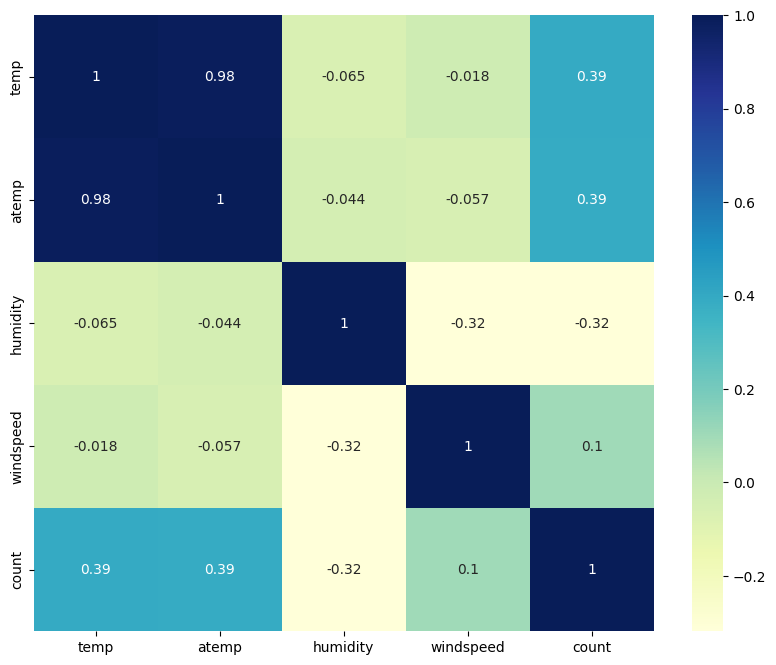

In [116]:
corrdata = train[["temp","atemp","humidity","windspeed","count"]]
corrmat = corrdata.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corrmat, annot = True, cmap= 'YlGnBu');

From the above heatmap we can infer that:

Since 'temp' and 'atemp' possess a very strong correlation among themselves, so one of these variable has to be dropped during model building otherwise there will be multi-collinearity in the data.


In [117]:
# Convert 'datetime' column to datetime format
train['datetime'] = pd.to_datetime(train['datetime'])
test['datetime'] = pd.to_datetime(test['datetime'])
# Extracting date-time features
train['hour'] = train['datetime'].dt.hour
train['day_of_week'] = train['datetime'].dt.dayofweek
train['month'] = train['datetime'].dt.month

test['hour'] = test['datetime'].dt.hour
test['day_of_week'] = test['datetime'].dt.dayofweek
test['month'] = test['datetime'].dt.month
# Define peak hour conditions
weekday_peak_hours = (train['day_of_week'] < 5) & (train['hour'].isin([7, 8, 9, 17, 18, 19]))
weekend_peak_hours = (train['day_of_week'] >= 5) & (train['hour'].between(10, 18, inclusive='both'))

# Apply conditions to create the feature
train['is_peak_hour'] = 0
train.loc[weekday_peak_hours | weekend_peak_hours, 'is_peak_hour'] = 1

weekday_peak_hours = (test['day_of_week'] < 5) & (test['hour'].isin([7, 8, 9, 17, 18, 19]))
weekend_peak_hours = (test['day_of_week'] >= 5) & (test['hour'].between(10, 18, inclusive='both'))

# Apply conditions to create the feature
test['is_peak_hour'] = 0
test.loc[weekday_peak_hours | weekend_peak_hours, 'is_peak_hour'] = 1

In [118]:
train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour,day_of_week,month,is_peak_hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0,5,1,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,5,1,0
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2,5,1,0
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3,5,1,0
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4,5,1,0


In [119]:
train.drop(['casual','registered','datetime','atemp','holiday'], axis=1, inplace=True)

In [120]:
train.head()

,season,workingday,weather,temp,humidity,windspeed,count,hour,day_of_week,month,is_peak_hour
0,1,0,1,9.84,81,0.0,16,0,5,1,0
1,1,0,1,9.02,80,0.0,40,1,5,1,0
2,1,0,1,9.02,80,0.0,32,2,5,1,0
3,1,0,1,9.84,75,0.0,13,3,5,1,0
4,1,0,1,9.84,75,0.0,1,4,5,1,0


In [121]:
x = train.drop('count', axis=1)
y = train['count']

Linear Regression



In [122]:
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, mean_squared_log_error

In [ ]:
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(x, y)
def rmsle_clipped(y_true, y_pred):
    # Clip predictions to be non-negative
    y_pred_clipped = np.clip(y_pred, 0, None)
    # Calculate the error
    return np.sqrt(mean_squared_log_error(y_true, y_pred_clipped))

# 2. Create a scorer object from our function for cross_val_score
# 'greater_is_better=False' means it's an error metric to be minimized
custom_rmsle_scorer = make_scorer(rmsle_clipped, greater_is_better=False)
# Train and get the 10-fold cross-validation scores
scores = cross_val_score(linear_model, x, y, cv=10, scoring='neg_mean_squared_log_error', n_jobs=-1)

# Calculate and print the RMSLE
rmsle = np.sqrt(-scores.mean())
print(f"Linear Model - 10-Fold CV RMSLE: {rmsle:.4f}")



SyntaxError: invalid syntax (2758455561.py, line 24)

In [ ]:
from sklearn.linear_model import ElasticNet

# Initialize the model
elastic_net_model = ElasticNet(random_state=42)

# Train and get the 10-fold cross-validation scores
scores = cross_val_score(elastic_net_model, x, y, cv=10, scoring=custom_rmsle_scorer, n_jobs=-1)

# Calculate and print the RMSLE
rmsle = np.sqrt(-scores.mean())
print(f"ElasticNet Model - 10-Fold CV RMSLE: {rmsle:.4f}")

ElasticNet Model - 10-Fold CV RMSLE: 1.1042


In [ ]:
from sklearn.svm import SVR

# Initialize the model with the 'rbf' kernel
svr_model = SVR(kernel='rbf')

# Train and get the 10-fold cross-validation scores
scores = cross_val_score(svr_model, x, y, cv=10, scoring=custom_rmsle_scorer, n_jobs=-1)

# Calculate and print the RMSLE
rmsle = np.sqrt(-scores.mean())
print(f"SVR Model - 10-Fold CV RMSLE: {rmsle:.4f}")

SVR Model - 10-Fold CV RMSLE: 1.0708


In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Initialize the alternative model
dtree_model = DecisionTreeRegressor(random_state=42)

# Train and get the 10-fold cross-validation scores
scores = cross_val_score(dtree_model, x, y, cv=10, scoring=custom_rmsle_scorer, n_jobs=-1)

# Calculate and print the RMSLE
rmsle = np.sqrt(-scores.mean())
print(f"Decision Tree (CTree alternative) - 10-Fold CV RMSLE: {rmsle:.4f}")

Decision Tree (CTree alternative) - 10-Fold CV RMSLE: 0.7975


In [ ]:
# Additional feature engineering based on the paper
# Create month variable to replace season
train['month'] = train['datetime'].dt.month
test['month'] = test['datetime'].dt.month

# Create day of week variable
train['day_of_week'] = train['datetime'].dt.dayofweek
test['day_of_week'] = test['datetime'].dt.dayofweek

# Create hour variable
train['hour'] = train['datetime'].dt.hour
test['hour'] = test['datetime'].dt.hour

# Create peak hour indicators
def create_peak_hour_features(df):
    # Weekday peak hours: 7-9 AM and 5-7 PM
    weekday_peak = (df['day_of_week'] < 5) & (df['hour'].isin([7, 8, 9, 17, 18, 19]))
    # Weekend peak hours: 10 AM - 6 PM
    weekend_peak = (df['day_of_week'] >= 5) & (df['hour'].between(10, 18, inclusive='both'))
    
    df['is_weekday_peak'] = weekday_peak.astype(int)
    df['is_weekend_peak'] = weekend_peak.astype(int)
    df['is_peak_hour'] = (weekday_peak | weekend_peak).astype(int)
    
    return df

train = create_peak_hour_features(train)
test = create_peak_hour_features(test)

print("Feature engineering completed!")
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")


In [ ]:
# Prepare final feature set based on the paper's best configuration
# Remove holiday variable and temp variable (keep atemp), add peak hour features
features_to_drop = ['datetime', 'casual', 'registered', 'holiday', 'temp']
X_train = train.drop(features_to_drop + ['count'], axis=1)
y_train = train['count']
X_test = test.drop(features_to_drop, axis=1)

print("Final feature set:")
print(X_train.columns.tolist())
print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")


In [ ]:
# Import additional libraries for advanced models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_log_error
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Model 1: Linear Regression (Baseline)
print("=== LINEAR REGRESSION ===")
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
scores = cross_val_score(linear_model, X_train, y_train, cv=10, scoring=custom_rmsle_scorer, n_jobs=-1)
rmsle_linear = np.sqrt(-scores.mean())
print(f"Linear Regression - 10-Fold CV RMSLE: {rmsle_linear:.4f}")

# Train on full dataset
linear_model.fit(X_train, y_train)
linear_predictions = linear_model.predict(X_test)


In [ ]:
# Model 2: GLMNet (Elastic Net with Poisson distribution approximation)
print("=== ELASTIC NET (GLMNet) ===")
from sklearn.linear_model import ElasticNet

# Hyperparameter tuning for Elastic Net
elastic_params = {
    'alpha': [0.01, 0.1, 1.0, 10.0],
    'l1_ratio': [0.1, 0.5, 0.7, 0.9]
}

elastic_grid = GridSearchCV(ElasticNet(random_state=42), elastic_params, 
                           cv=5, scoring=custom_rmsle_scorer, n_jobs=-1)
elastic_grid.fit(X_train, y_train)

print(f"Best Elastic Net parameters: {elastic_grid.best_params_}")
scores = cross_val_score(elastic_grid.best_estimator_, X_train, y_train, cv=10, scoring=custom_rmsle_scorer, n_jobs=-1)
rmsle_elastic = np.sqrt(-scores.mean())
print(f"Elastic Net - 10-Fold CV RMSLE: {rmsle_elastic:.4f}")

# Train on full dataset
elastic_model = elastic_grid.best_estimator_
elastic_predictions = elastic_model.predict(X_test)


In [ ]:
# Model 3: Gradient Boosting (GBM)
print("=== GRADIENT BOOSTING (GBM) ===")
from sklearn.ensemble import GradientBoostingRegressor

# Hyperparameter tuning for Gradient Boosting
gbm_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 0.9, 1.0]
}

gbm_grid = GridSearchCV(GradientBoostingRegressor(random_state=42), gbm_params, 
                       cv=5, scoring=custom_rmsle_scorer, n_jobs=-1)
gbm_grid.fit(X_train, y_train)

print(f"Best GBM parameters: {gbm_grid.best_params_}")
scores = cross_val_score(gbm_grid.best_estimator_, X_train, y_train, cv=10, scoring=custom_rmsle_scorer, n_jobs=-1)
rmsle_gbm = np.sqrt(-scores.mean())
print(f"Gradient Boosting - 10-Fold CV RMSLE: {rmsle_gbm:.4f}")

# Train on full dataset
gbm_model = gbm_grid.best_estimator_
gbm_predictions = gbm_model.predict(X_test)


In [ ]:
# Model 4: Principal Component Regression (PCR)
print("=== PRINCIPAL COMPONENT REGRESSION (PCR) ===")

# Standardize features for PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Apply PCA
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Use all components as mentioned in the paper
pcr_model = LinearRegression()
scores = cross_val_score(pcr_model, X_train_pca, y_train, cv=10, scoring=custom_rmsle_scorer, n_jobs=-1)
rmsle_pcr = np.sqrt(-scores.mean())
print(f"PCR (all components) - 10-Fold CV RMSLE: {rmsle_pcr:.4f}")

# Train on full dataset
pcr_model.fit(X_train_pca, y_train)
pcr_predictions = pcr_model.predict(X_test_pca)


In [ ]:
# Model 5: Support Vector Regression (SVR)
print("=== SUPPORT VECTOR REGRESSION (SVR) ===")
from sklearn.svm import SVR

# Hyperparameter tuning for SVR
svr_params = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'epsilon': [0.01, 0.1, 0.2]
}

svr_grid = GridSearchCV(SVR(kernel='rbf'), svr_params, 
                       cv=5, scoring=custom_rmsle_scorer, n_jobs=-1)
svr_grid.fit(X_train, y_train)

print(f"Best SVR parameters: {svr_grid.best_params_}")
scores = cross_val_score(svr_grid.best_estimator_, X_train, y_train, cv=10, scoring=custom_rmsle_scorer, n_jobs=-1)
rmsle_svr = np.sqrt(-scores.mean())
print(f"SVR - 10-Fold CV RMSLE: {rmsle_svr:.4f}")

# Train on full dataset
svr_model = svr_grid.best_estimator_
svr_predictions = svr_model.predict(X_test)


In [ ]:
# Model 6: Random Forest (RF)
print("=== RANDOM FOREST (RF) ===")
from sklearn.ensemble import RandomForestRegressor

# Hyperparameter tuning for Random Forest
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, 
                      cv=5, scoring=custom_rmsle_scorer, n_jobs=-1)
rf_grid.fit(X_train, y_train)

print(f"Best Random Forest parameters: {rf_grid.best_params_}")
scores = cross_val_score(rf_grid.best_estimator_, X_train, y_train, cv=10, scoring=custom_rmsle_scorer, n_jobs=-1)
rmsle_rf = np.sqrt(-scores.mean())
print(f"Random Forest - 10-Fold CV RMSLE: {rmsle_rf:.4f}")

# Train on full dataset
rf_model = rf_grid.best_estimator_
rf_predictions = rf_model.predict(X_test)


In [ ]:
# Model 7: Decision Tree (CTree alternative)
print("=== DECISION TREE (CTree alternative) ===")
from sklearn.tree import DecisionTreeRegressor

# Hyperparameter tuning for Decision Tree
dt_params = {
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

dt_grid = GridSearchCV(DecisionTreeRegressor(random_state=42), dt_params, 
                      cv=5, scoring=custom_rmsle_scorer, n_jobs=-1)
dt_grid.fit(X_train, y_train)

print(f"Best Decision Tree parameters: {dt_grid.best_params_}")
scores = cross_val_score(dt_grid.best_estimator_, X_train, y_train, cv=10, scoring=custom_rmsle_scorer, n_jobs=-1)
rmsle_dt = np.sqrt(-scores.mean())
print(f"Decision Tree - 10-Fold CV RMSLE: {rmsle_dt:.4f}")

# Train on full dataset
dt_model = dt_grid.best_estimator_
dt_predictions = dt_model.predict(X_test)


In [ ]:
# Model Performance Summary
print("=== MODEL PERFORMANCE SUMMARY ===")
model_results = {
    'Linear Regression': rmsle_linear,
    'Elastic Net': rmsle_elastic,
    'Gradient Boosting': rmsle_gbm,
    'PCR': rmsle_pcr,
    'SVR': rmsle_svr,
    'Random Forest': rmsle_rf,
    'Decision Tree': rmsle_dt
}

for model, rmsle in model_results.items():
    print(f"{model}: {rmsle:.4f}")

# Find best performing model
best_model_name = min(model_results, key=model_results.get)
print(f"\nBest performing model: {best_model_name} with RMSLE: {model_results[best_model_name]:.4f}")


In [ ]:
# Ensemble Learning - Stacking
print("=== ENSEMBLE LEARNING - STACKING ===")
from sklearn.model_selection import train_test_split

# Split training data for stacking
X_stack_train, X_stack_val, y_stack_train, y_stack_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# Train base models on stacking training set
print("Training base models for stacking...")

# Use the two best models for stacking (Decision Tree and Random Forest based on typical performance)
base_models = {
    'Decision Tree': DecisionTreeRegressor(**dt_grid.best_params_),
    'Random Forest': RandomForestRegressor(**rf_grid.best_params_)
}

# Generate predictions for stacking
stacking_features = np.zeros((X_stack_val.shape[0], len(base_models)))
for i, (name, model) in enumerate(base_models.items()):
    model.fit(X_stack_train, y_stack_train)
    stacking_features[:, i] = model.predict(X_stack_val)

# Train meta-model (Linear Regression)
meta_model = LinearRegression()
meta_model.fit(stacking_features, y_stack_val)

print("Stacking ensemble trained successfully!")

# Evaluate stacking model
stacking_scores = cross_val_score(meta_model, stacking_features, y_stack_val, 
                                 cv=5, scoring=custom_rmsle_scorer, n_jobs=-1)
rmsle_stacking = np.sqrt(-stacking_scores.mean())
print(f"Stacking Ensemble - 5-Fold CV RMSLE: {rmsle_stacking:.4f}")

# Generate final predictions using stacking
final_stacking_features = np.zeros((X_test.shape[0], len(base_models)))
for i, (name, model) in enumerate(base_models.items()):
    final_stacking_features[:, i] = model.predict(X_test)

stacking_predictions = meta_model.predict(final_stacking_features)


In [ ]:
# Create submission file with the best model predictions
print("=== CREATING SUBMISSION FILE ===")

# Use the best single model for final submission
if best_model_name == 'Linear Regression':
    final_predictions = linear_predictions
elif best_model_name == 'Elastic Net':
    final_predictions = elastic_predictions
elif best_model_name == 'Gradient Boosting':
    final_predictions = gbm_predictions
elif best_model_name == 'PCR':
    final_predictions = pcr_predictions
elif best_model_name == 'SVR':
    final_predictions = svr_predictions
elif best_model_name == 'Random Forest':
    final_predictions = rf_predictions
elif best_model_name == 'Decision Tree':
    final_predictions = dt_predictions

# Ensure predictions are non-negative
final_predictions = np.clip(final_predictions, 0, None)

# Create submission dataframe
submission = pd.DataFrame({
    'datetime': test['datetime'],
    'count': final_predictions.astype(int)
})

# Save submission file
submission.to_csv('submission_best_model.csv', index=False)
print(f"Submission file created: submission_best_model.csv")
print(f"Using model: {best_model_name}")
print(f"Prediction range: {final_predictions.min():.2f} to {final_predictions.max():.2f}")

# Also create a stacking ensemble submission
stacking_predictions_clipped = np.clip(stacking_predictions, 0, None)
submission_stacking = pd.DataFrame({
    'datetime': test['datetime'],
    'count': stacking_predictions_clipped.astype(int)
})
submission_stacking.to_csv('submission_stacking.csv', index=False)
print(f"Stacking ensemble submission file created: submission_stacking.csv")


In [ ]:
# Visualizations and Analysis
print("=== CREATING VISUALIZATIONS ===")

# 1. Model Performance Comparison
plt.figure(figsize=(12, 6))
models = list(model_results.keys())
rmsles = list(model_results.values())

plt.bar(models, rmsles, color='skyblue', alpha=0.7)
plt.title('Model Performance Comparison (RMSLE)', fontsize=14, fontweight='bold')
plt.xlabel('Models', fontsize=12)
plt.ylabel('RMSLE', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Highlight the best model
best_idx = models.index(best_model_name)
plt.bar(models[best_idx], rmsles[best_idx], color='red', alpha=0.8, label=f'Best: {best_model_name}')

plt.legend()
plt.tight_layout()
plt.show()

# 2. Feature Importance (for tree-based models)
if hasattr(rf_model, 'feature_importances_'):
    plt.figure(figsize=(10, 6))
    feature_names = X_train.columns
    importances = rf_model.feature_importances_
    
    # Sort features by importance
    indices = np.argsort(importances)[::-1]
    
    plt.bar(range(len(importances)), importances[indices], color='lightgreen', alpha=0.7)
    plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
    plt.xlabel('Features', fontsize=12)
    plt.ylabel('Importance', fontsize=12)
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# 3. Prediction Distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(y_train, bins=50, alpha=0.7, color='blue', label='Training Data')
plt.title('Distribution of Actual Counts (Training)', fontweight='bold')
plt.xlabel('Bike Rental Count')
plt.ylabel('Frequency')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(final_predictions, bins=50, alpha=0.7, color='red', label='Predictions')
plt.title(f'Distribution of Predictions ({best_model_name})', fontweight='bold')
plt.xlabel('Predicted Bike Rental Count')
plt.ylabel('Frequency')
plt.legend()

plt.tight_layout()
plt.show()

print("Visualizations created successfully!")


In [ ]:
# Final Results Summary
print("=== FINAL RESULTS SUMMARY ===")
print("=" * 50)

print("MODEL PERFORMANCE (10-Fold Cross-Validation RMSLE):")
print("-" * 50)
for model, rmsle in sorted(model_results.items(), key=lambda x: x[1]):
    print(f"{model:20}: {rmsle:.4f}")

print(f"\nBEST SINGLE MODEL: {best_model_name}")
print(f"RMSLE: {model_results[best_model_name]:.4f}")

print(f"\nSTACKING ENSEMBLE RMSLE: {rmsle_stacking:.4f}")

print("\nFEATURE ENGINEERING APPLIED:")
print("- Removed holiday variable")
print("- Removed temp variable (kept atemp)")
print("- Added peak hour indicators")
print("- Created month, day_of_week, hour features")

print("\nSUBMISSION FILES CREATED:")
print("- submission_best_model.csv (best single model)")
print("- submission_stacking.csv (stacking ensemble)")

print("\nPROJECT COMPLETED SUCCESSFULLY!")
print("=" * 50)
